# 02 - Analisi esplorativa
Qui guardiamo l'andamento della domanda nel tempo e le differenze tra magazzini.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/demand.csv")


df["Order_Demand"] = ( #Convertiamo Order_Demand in numero (come nel notebook 01)
    df["Order_Demand"]
    .astype(str)
    .str.strip()
    .str.replace("(", "-", regex=False)
    .str.replace(")", "", regex=False)
)
df["Order_Demand"] = pd.to_numeric(df["Order_Demand"])

In [2]:
#Date è testo. Per fare grafici nel tempo deve essere nel giusto formato.
df["Date"] = pd.to_datetime(df["Date"], format="%Y/%m/%d")

print(df["Date"].dtype)
print("Dal:", df["Date"].min(),"Al:", df["Date"].max()) #range data


datetime64[us]
Dal: 2011-01-08 00:00:00 Al: 2017-01-09 00:00:00


In [3]:
senza_data = df["Date"].isna() #separo le righe senza data senza cancellarle

#due tabelle
df_no_date = df[senza_data].copy() #messa da parte
df_with_date = df[~senza_data].copy() #per i grafici

# Controllo: i due pezzi sommati devono dare il totale
print("Senza data:", len(df_no_date))
print("Con data:  ", len(df_with_date))
print("Totale:    ", len(df))

Senza data: 11239
Con data:   1037336
Totale:     1048575


In [4]:
df.shape #check con il totale

(1048575, 5)

## 1. Domanda totale nel tempo
Sommiamo Order_Demand per mese (tutti i prodotti e tutti i magazzini insieme).
I resi (valori negativi) sono inclusi nella somma, quindi vediamo la domanda netta.

In [5]:
df_with_date["Mese"] = df_with_date["Date"].dt.to_period("M")

# Raggruppiamo per mese e sommiamo Order_Demand: un valore per ogni mese
domanda_mensile = df_with_date.groupby("Mese")["Order_Demand"].sum()

# Guardiamo i primi e gli ultimi mesi per controllo
print(domanda_mensile.head())
print(domanda_mensile.tail())

Mese
2011-01        2
2011-05      108
2011-06    92000
2011-09     6728
2011-10       -1
Freq: M, Name: Order_Demand, dtype: int64
Mese
2016-09    77610066
2016-10    83854187
2016-11    89849906
2016-12    80306310
2017-01      294967
Freq: M, Name: Order_Demand, dtype: int64


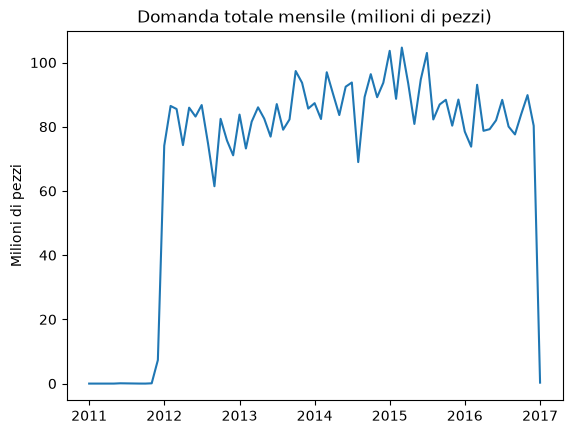

In [6]:
# Disegniamo la domanda mensile, in milioni di pezzi per leggere meglio i numeri
plt.plot(domanda_mensile.index.to_timestamp(), domanda_mensile.values / 1e6)

plt.title("Domanda totale mensile (milioni di pezzi)")
plt.ylabel("Milioni di pezzi")

plt.show()

### Cosa osserviamo nel grafico

- **2011:** la domanda mensile è quasi zero (valori da -1 a 92.000 pezzi, contro circa 80 milioni
  negli altri mesi). Con ogni probabilità sono pochissimi record, non una domanda reale così bassa:
  il dataset sembra iniziare davvero a gennaio 2012.
- **Gennaio 2017:** solo 294.967 pezzi. Il dataset termina il 9 gennaio 2017, quindi il mese è incompleto.
- **Periodo affidabile: gennaio 2012 - dicembre 2016** (60 mesi). La domanda mensile oscilla
  tra circa 60 e 105 milioni di pezzi, con una leggera crescita fino al 2015 e poi un andamento più stabile.
- **Stagionalità:** a prima vista non è evidente. La verificheremo con un grafico per mese dell'anno.

**Decisione:** per la previsione useremo solo il periodo gennaio 2012 - dicembre 2016.
Non cancelliamo nulla dal dataset originale: escludiamo questi mesi solo dall'analisi,
perché un mese incompleto farebbe credere al modello che la domanda sia crollata.

## 2. Domanda per magazzino
Confrontiamo quanto pesa ogni magazzino sulla domanda totale.
Usiamo solo il periodo affidabile: gennaio 2012 - dicembre 2016.

In [7]:
# Teniamo solo le righe tra il 1 gennaio 2012 e il 31 dicembre 2016 (periodo affidabile)
df_analisi = df_with_date[
    (df_with_date["Date"] >= "2012-01-01") & (df_with_date["Date"] <= "2016-12-31")
].copy()

# Controllo: quante righe restano
print("Righe nel periodo affidabile:", len(df_analisi))

Righe nel periodo affidabile: 1036643


In [8]:
domanda_magazzino = df_analisi.groupby("Warehouse")["Order_Demand"].sum().sort_values(ascending=False) #sommare per magazzino
print(domanda_magazzino)

Warehouse
Whse_J    3344066262
Whse_S    1030165015
Whse_C     578777987
Whse_A     143038014
Name: Order_Demand, dtype: int64


In [9]:
percentuale = (domanda_magazzino / domanda_magazzino.sum() * 100).round(1)
print(percentuale)

Warehouse
Whse_J    65.6
Whse_S    20.2
Whse_C    11.4
Whse_A     2.8
Name: Order_Demand, dtype: float64


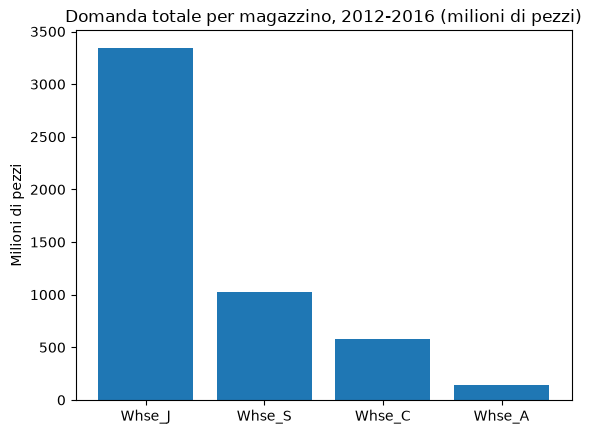

In [10]:
plt.bar(domanda_magazzino.index, domanda_magazzino.values / 1e6)

plt.title("Domanda totale per magazzino, 2012-2016 (milioni di pezzi)")
plt.ylabel("Milioni di pezzi")

plt.show()

## 2. Domanda per magazzino

**Cosa abbiamo fatto:** abbiamo sommato la domanda di ogni magazzino nel periodo affidabile
(gennaio 2012 - dicembre 2016, 1.036.643 righe) e confrontato i totali.

**Risultato:**
- Il magazzino più grande è **Whse_J**, con circa 3.344 milioni di pezzi (**65,6%** del totale).
- Segue **Whse_S** con circa 1.030 milioni di pezzi (**20,2%**), poi **Whse_C** con circa 579 milioni (**11,4%**)
  e infine **Whse_A** con circa 143 milioni (**2,8%**).
- La domanda è **molto concentrata**: Whse_J pesa da solo circa due terzi del totale, e insieme
  a Whse_S si arriva all'85,8%. Whse_A è marginale.

**Perché è utile:** se un magazzino concentra gran parte della domanda, i suoi errori di previsione
pesano di più sull'azienda. Whse_J e Whse_S sono quindi i magazzini su cui conviene concentrare
l'attenzione, mentre Whse_A ha un impatto limitato. Possiamo decidere se prevedere la domanda
per ogni magazzino separatamente o per tutti insieme.

**Limiti:**
- Il grafico mostra il totale del periodo e non dice se il peso dei magazzini è cambiato nel tempo.
- "Domanda" significa pezzi richiesti, non necessariamente consegnati.
- Il confronto è in numero di pezzi: non tiene conto del valore economico dei prodotti.

## 3. Stagionalità: domanda per mese dell'anno
Sommiamo la domanda di tutti i gennaio, tutti i febbraio, ecc. (2012-2016) per vedere se ci sono
mesi che pesano di più. Usiamo solo anni completi, così ogni mese è confrontabile.

In [11]:
df_analisi["Mese_numero"] = df_analisi["Date"].dt.month

domanda_per_mese = df_analisi.groupby("Mese_numero")["Order_Demand"].sum()

# Mostriamo i valori in milioni di pezzi, senza decimali
print((domanda_per_mese / 1e6).round(0))

Mese_numero
1     427.0
2     405.0
3     462.0
4     423.0
5     412.0
6     429.0
7     459.0
8     385.0
9     398.0
10    448.0
11    429.0
12    419.0
Name: Order_Demand, dtype: float64


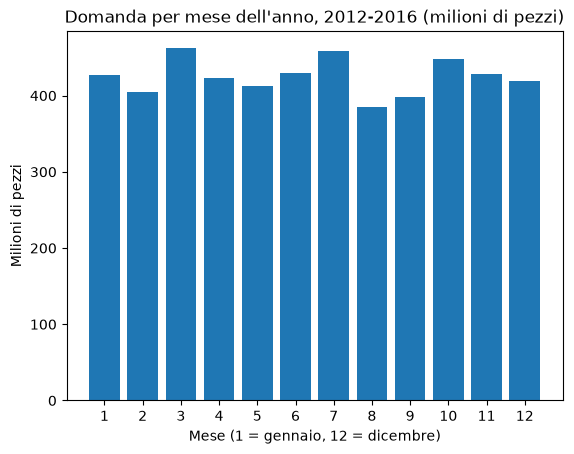

In [12]:
plt.bar(domanda_per_mese.index, domanda_per_mese.values / 1e6)

plt.xticks(range(1, 13)) #Mostriamo tutti i numeri da 1 a 12 sull'asse orizzontale

plt.title("Domanda per mese dell'anno, 2012-2016 (milioni di pezzi)")
plt.xlabel("Mese (1 = gennaio, 12 = dicembre)")
plt.ylabel("Milioni di pezzi")

plt.show()

## 3. Stagionalità: domanda per mese dell'anno

**Cosa abbiamo fatto:** abbiamo sommato la domanda di tutti i gennaio, tutti i febbraio, ecc.
nei 5 anni completi (2012-2016), per vedere se alcuni mesi pesano sistematicamente di più.

**Risultato (milioni di pezzi):**
- I mesi più alti sono **marzo (462)**, **luglio (459)** e **ottobre (448)**.
- I mesi più bassi sono **agosto (385)**, **settembre (398)** e **febbraio (405)**.
- La media mensile è di circa 425 milioni di pezzi. Il mese più alto è circa il 9% sopra la media
  e il più basso circa il 9% sotto.

**Interpretazione:** la stagionalità è **debole**. Le differenze tra i mesi sono contenute e non c'è
un periodo dell'anno in cui la domanda cambia in modo netto. Due note:
- Agosto è il mese più basso: potrebbe dipendere dalle ferie estive, ma è solo un'ipotesi
  che il dataset non permette di verificare.
- Febbraio è basso in buona parte perché ha meno giorni degli altri mesi.

**Perché è utile:** un modello di previsione può usare il mese come informazione, ma non ci
aspettiamo che migliori molto i risultati. Contano di più l'andamento nel tempo e il comportamento
dei singoli prodotti.

**Limiti:**
- Il grafico somma 5 anni insieme: se un anno fosse molto diverso, potrebbe influenzare il risultato.
- Mostra il totale di tutti i prodotti e magazzini, mentre singoli prodotti potrebbero avere una stagionalità
  più forte che qui si compensa.
- L'asse parte da zero, quindi le barre sembrano simili tra loro: è corretto, ma le differenze reali
  vanno lette nei numeri.